# Amazon Stock Data: Exploratory Data Analysis

## Project objective
Explore historical Amazon stock data and prepare the closing-price series for an LSTM model that predicts the next trading day's closing price using the previous seven observations.

## Dataset
The supplied dataset, `MZN.csv`, contains 6,516 trading-day observations from May 15, 1997, to April 5, 2023.

Available columns include Date, Open, High, Low, Close, Adj Close, and Volume. This project uses **Close** as the prediction target.

## Workflow
1. Inspect the dataset structure and data quality.
2. Convert dates into a datetime index.
3. Visualize closing prices and trading volume.
4. Export the closing-price series for the modeling notebook.

In [1]:
# !pip install pandas torch scikit-learn matplotlib numpy

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('MZN.csv')

## Data inspection

Check the dataset dimensions, column types, missing values, and duplicate records. Preview both ends of the dataset to establish its historical coverage.

In [4]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,15-05-1997,0.121875,0.125000,0.096354,0.097917,0.097917,1443120000
1,16-05-1997,0.098438,0.098958,0.085417,0.086458,0.086458,294000000
2,19-05-1997,0.088021,0.088542,0.081250,0.085417,0.085417,122136000
3,20-05-1997,0.086458,0.087500,0.081771,0.081771,0.081771,109344000
4,21-05-1997,0.081771,0.082292,0.068750,0.071354,0.071354,377064000


In [5]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
6511,30-03-2023,101.550003,103.040001,101.010002,102.000000,102.000000,53633400
6512,31-03-2023,102.160004,103.489998,101.949997,103.290001,103.290001,56704300
6513,03-04-2023,102.300003,103.290001,101.430000,102.410004,102.410004,41135700
6514,04-04-2023,102.750000,104.199997,102.110001,103.949997,103.949997,48662500
6515,05-04-2023,103.910004,103.910004,100.750000,101.099998,101.099998,45103000


In [6]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='str')

In [7]:
df.shape

(6516, 7)

In [8]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,6516.000000,6516.000000,6516.000000,6516.000000,6516.000000,6.516000e+03
mean,31.611626,31.991995,31.193432,31.599740,31.599740,1.425338e+08
std,48.095343,48.659651,47.464476,48.060258,48.060258,1.401619e+08
min,0.070313,0.072396,0.065625,0.069792,0.069792,9.744000e+06
25%,1.998875,2.028500,1.964750,2.001250,2.001250,6.888182e+07
50%,6.456750,6.535500,6.353250,6.444250,6.444250,1.059050e+08
75%,38.451375,38.688000,38.203001,38.464625,38.464625,1.607700e+08
max,187.199997,188.654007,184.839493,186.570496,186.570496,2.086584e+09


In [9]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['Date'] = pd.to_datetime(df['Date'])

C:\Users\KIIT\AppData\Local\Temp\ipykernel_2692\2394721818.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [12]:
df.index = df.Date

In [13]:
#df.drop(['Date'], axis=1, inplace=True)

In [14]:
df.index[0]

Timestamp('1997-05-15 00:00:00')

In [15]:
df.index[-1]

Timestamp('2023-04-05 00:00:00')

In [16]:
df.index

DatetimeIndex(['1997-05-15', '1997-05-16', '1997-05-19', '1997-05-20',
               '1997-05-21', '1997-05-22', '1997-05-23', '1997-05-27',
               '1997-05-28', '1997-05-29',
               ...
               '2023-03-23', '2023-03-24', '2023-03-27', '2023-03-28',
               '2023-03-29', '2023-03-30', '2023-03-31', '2023-04-03',
               '2023-04-04', '2023-04-05'],
              dtype='datetime64[us]', name='Date', length=6516, freq=None)

In [17]:
df

,Date,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,,
1997-05-15,1997-05-15,0.121875,0.125000,0.096354,0.097917,0.097917,1443120000
1997-05-16,1997-05-16,0.098438,0.098958,0.085417,0.086458,0.086458,294000000
1997-05-19,1997-05-19,0.088021,0.088542,0.081250,0.085417,0.085417,122136000
1997-05-20,1997-05-20,0.086458,0.087500,0.081771,0.081771,0.081771,109344000
1997-05-21,1997-05-21,0.081771,0.082292,0.068750,0.071354,0.071354,377064000
...,...,...,...,...,...,...,...
2023-03-30,2023-03-30,101.550003,103.040001,101.010002,102.000000,102.000000,53633400
2023-03-31,2023-03-31,102.160004,103.489998,101.949997,103.290001,103.290001,56704300
2023-04-03,2023-04-03,102.300003,103.290001,101.430000,102.410004,102.410004,41135700


## Closing prices and trading volume

These plots show how closing prices and trading activity vary over the dataset's history. Changes in price level across periods are relevant because the model is trained on earlier observations and evaluated on later observations.

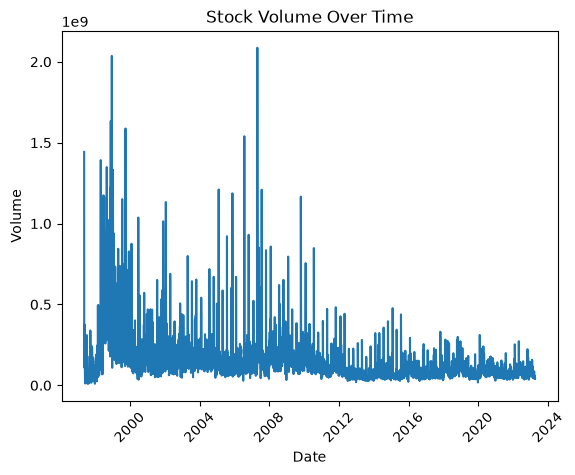

In [18]:
plt.plot(df.index, df['Volume'])
plt.xlabel('Date')
plt.ylabel('Volume')
plt.title('Stock Volume Over Time')
plt.xticks(rotation=45)
plt.show()

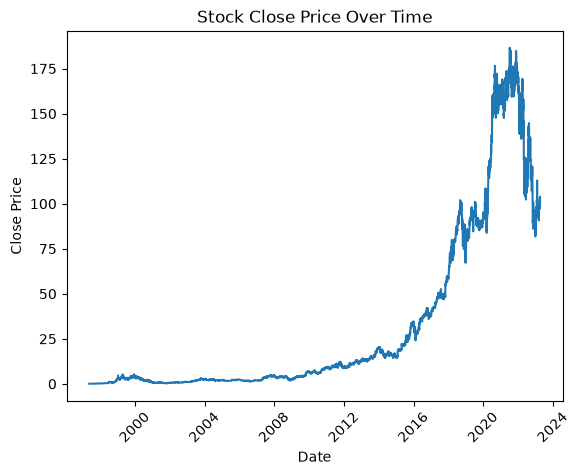

In [19]:
plt.plot(df.index, df['Close'], label='Close')
#plt.xticks([])
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Stock Close Price Over Time')
plt.xticks( rotation=45)
plt.show()

## Findings and exported data

- The supplied dataset contains no missing values or duplicate rows.
- The dates are chronologically ordered and contain no duplicate dates.
- Closing prices vary substantially across the historical period.
- The closing-price series is exported as `Amazon_stock_closing_prices.csv`, with dates retained for chronological splitting and visualization.

The modeling notebook uses this exported file to construct seven-observation input windows.

In [20]:
data = df['Close']

In [21]:
data

Date
1997-05-15      0.097917
1997-05-16      0.086458
1997-05-19      0.085417
1997-05-20      0.081771
1997-05-21      0.071354
                 ...    
2023-03-30    102.000000
2023-03-31    103.290001
2023-04-03    102.410004
2023-04-04    103.949997
2023-04-05    101.099998
Name: Close, Length: 6516, dtype: float64

In [22]:
data.to_csv('Amazon_stock_closing_prices.csv')
print('Data retrieved and saved to Amazon_stock_closing_prices.csv')

Data retrieved and saved to Amazon_stock_closing_prices.csv
